### ViT 스크래치 모델 기반 Food 이미지 학습

하이퍼파라미터 설정 (8GB VRAM 최적화)

In [2]:
import os, torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
from torch.nn import functional as F
import torchvision
import torchvision.transforms as transforms

batch_size = 128   
learning_rate = 3e-4 
epochs = 30
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 모델 아키텍처 사이즈 (VRAM을 4~6GB까지 끌어다 쓰도록 볼륨업!)
img_size = 128      # 고해상도 학습 (원본 사진이 크므로 128x128 사용)
patch_size = 16     # 128x128 이미지를 16x16 패치로 분할 (총 64개 패치)
n_embd = 384        # 모델 표현력 대폭 증가 (256 -> 384)
n_head = 6          # 384 // 6 = 64차원 헤드
num_blks = 6        # 트랜스포머 블록 깊이 증가 (4 -> 6)
emb_dropout = blk_dropout = 0.1
num_classes = 101   # Food101은 101개 클래스


Food101 데이터셋 로드 (101,000장 고해상도 실제 사진)

In [3]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)), 
    transforms.RandomHorizontalFlip(p=0.5),         
    transforms.RandomRotation(15),                  
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Food101 데이터셋을 다운로드하고 준비합니다. (약 5GB, 수 분 소요)...")
cur_module_folder = "./"

# CIFAR와 달리 인자가 train=True가 아니라 split='train' 입니다.
trainset = torchvision.datasets.Food101(root=os.path.join(cur_module_folder, 'data'), split='train', download=True, transform=train_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0) # Windows에서는 num_workers=0 권장

testset = torchvision.datasets.Food101(root=os.path.join(cur_module_folder, 'data'), split='test', download=True, transform=test_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

classes = trainset.classes  # 101가지 음식 이름 리스트


Food101 데이터셋을 다운로드하고 준비합니다. (약 5GB, 수 분 소요)...


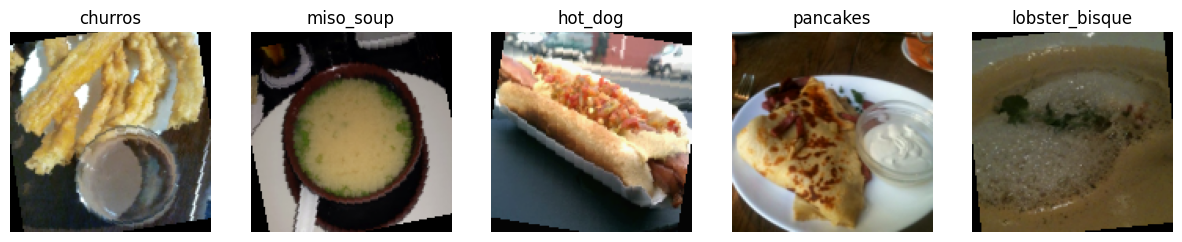

In [4]:
# 데이터셋 샘플 시각화
dataiter = iter(trainloader)
images, labels = next(dataiter)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.transpose(img, (1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    # 클래스 이름이 길 수 있으므로 15자로 자름
    axes[i].set_title(f"{classes[labels[i]][:15]}")
    axes[i].axis('off')
    
ouptut_fname = os.path.join(cur_module_folder, "food101_samples.png")
plt.savefig(ouptut_fname)
plt.show()

ViT 모델 아키텍처

In [ ]:
class PatchEmbeddings(nn.Module):
    def __init__(self, img_size, patch_size, hidden_dim):
        super().__init__()
        self.conv = nn.Conv2d(in_channels=3, out_channels=hidden_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, X):
        X = self.conv(X)
        X = X.flatten(2) 
        X = X.transpose(1, 2)
        return X

class Head(nn.Module): 
    def __init__(self, n_embd, head_size, dropout=0.1, is_decoder=False):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)    
        self.query = nn.Linear(n_embd, head_size, bias=False)  
        self.value = nn.Linear(n_embd, head_size, bias=False)  
        self.dropout = nn.Dropout(dropout)      
        self.is_decoder = is_decoder            
    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        wei = q @ k.transpose(-2, -1) * (C**-0.5) 
        if self.is_decoder:
            tril = torch.tril(torch.ones(T, T, dtype=torch.bool, device=device))
            wei = wei.masked_fill(tril == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        return wei @ v

class MultiHeadAttention(nn.Module): 
    def __init__(self, n_embd, num_heads, dropout=0.1, is_decoder=False):
        super().__init__()
        assert n_embd % num_heads == 0
        self.heads = nn.ModuleList([Head(n_embd, n_embd // num_heads, dropout, is_decoder) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd) 
        self.dropout = nn.Dropout(dropout)  
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

class Block(nn.Module): 
    def __init__(self, n_embd, num_heads, dropout=0.1, is_decoder=False):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd) 
        self.attn = MultiHeadAttention(n_embd, num_heads, dropout, is_decoder) 
        self.ln2 = nn.LayerNorm(n_embd) 
        self.ffn = nn.Sequential(nn.Linear(n_embd, 4 * n_embd), nn.GELU(), nn.Linear(4 * n_embd, n_embd)) 
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

class ViT(nn.Module): 
    def __init__(self, img_size, patch_size, num_hiddens, num_heads, num_blks, emb_dropout, blk_dropout, num_classes):
        super().__init__()
        self.patch_embedding = PatchEmbeddings(img_size, patch_size, num_hiddens)  
        self.cls_token = nn.Parameter(torch.zeros(1, 1, num_hiddens))              
        num_patches = (img_size // patch_size) ** 2
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, num_hiddens) * 0.02)    
        self.dropout = nn.Dropout(emb_dropout)                                     
        self.blocks = nn.ModuleList([Block(num_hiddens, num_heads, blk_dropout, is_decoder=False) for _ in range(num_blks)]) 
        self.layer_norm = nn.LayerNorm(num_hiddens) 
        self.classifier = nn.Linear(num_hiddens, num_classes) 

    def forward(self, X):
        x = self.patch_embedding(X)
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        cls_output = self.layer_norm(x[:, 0]) 
        logits = self.classifier(cls_output)    
        return logits


학습 루프 및 검증

In [ ]:
print(f"1. 모델 초기화 (디바이스: {device})")
model = ViT(img_size, patch_size, n_embd, n_head, num_blks, emb_dropout, blk_dropout, num_classes).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# [수정됨] CosineAnnealingLR은 매 배치(혹은 에폭)마다 step()만 호출해야 함 (val_loss 입력 X)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

print("2. Food101 학습 시작")
best_val_loss = float('inf')
model_fname = ''
patience = 5  
patience_counter = 0

모델 예측 (랜덤 샘플링으로 다양한 클래스 확인)


[예측 결과 샘플 확인]
정답: clam_chowder -> 모델 예측: clam_chowder
정답: takoyaki -> 모델 예측: pork_chop
정답: samosa -> 모델 예측: samosa
정답: apple_pie -> 모델 예측: deviled_eggs
정답: chocolate_mousse -> 모델 예측: foie_gras


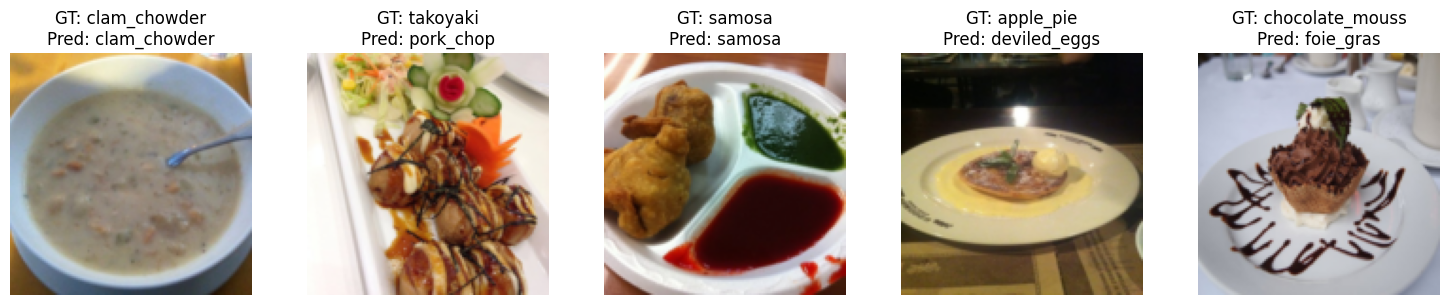

In [ ]:
model_fname = os.path.join(cur_module_folder, f"best_vit_food101.pth")

print("\n[예측 결과 샘플 확인]")
model.load_state_dict(torch.load(model_fname))
model.eval()

# 랜덤하게 5개 샘플 선택 (다양한 클래스 확인을 위해)
random_indices = torch.randperm(len(testset))[:5]
sample_images = []
sample_labels = []
for idx in random_indices:
    img, label = testset[idx]
    sample_images.append(img)
    sample_labels.append(label)

images = torch.stack(sample_images).to(device)
labels = torch.tensor(sample_labels).to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for j in range(5):
    img = images[j].cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.transpose(img, (1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)

    axes[j].imshow(img)
    pred_cls = classes[predicted[j]][:15]
    gt_cls = classes[labels[j]][:15]
    axes[j].set_title(f"GT: {gt_cls}\nPred: {pred_cls}")
    axes[j].axis('off')
    print(f"정답: {classes[labels[j]]} -> 모델 예측: {classes[predicted[j]]}")

plt.tight_layout()
output_fname = os.path.join(cur_module_folder, "vit_food101_predictions.png")
plt.savefig(output_fname) 
plt.show()